## MR4010 Navegacion autonoma

### Transformada de Hough y pipeline.

Referencia imagen original de ejercicio

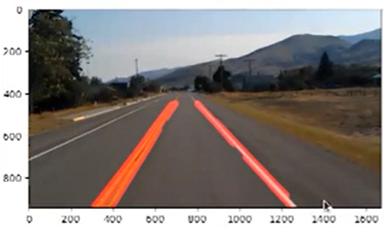

Pipeline clásico de visión para carriles:

Grayscale

Gaussian Blur

Canny Edge Detection

ROI (máscara)

Hough Transform (líneas)

Overlay final

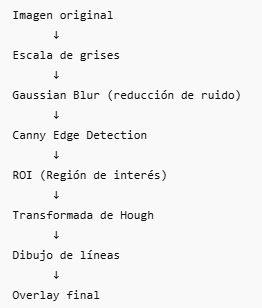

https://docs.opencv.org/3.4/d9/db0/tutorial_hough_lines.html

#### 1. LIBRERÍAS

In [1]:
# ==============================
# 1. LIBRERÍAS
# ==============================
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2

#### 2. CARGA DE IMAGEN + CANNY

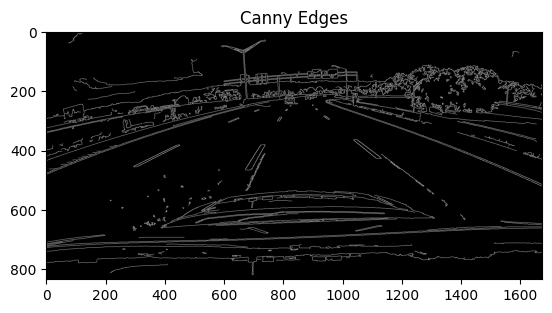

Shape: (835, 1674)


In [ ]:
# ==============================
# 2. CARGA DE IMAGEN + CANNY
# ==============================
IMAGE_PATH = "D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\Module1\Self_Driving_Car_ROADCAMERA.jpg"  # Cambia si es necesario

img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise ValueError("No se pudo cargar la imagen. Verifica la ruta.")

# Convertir a escala de grises
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Blur para reducir ruido
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Canny (detección de bordes)
img_canny = cv2.Canny(img_blur, 40, 120)

plt.imshow(img_canny, cmap='gray')
plt.title("Canny Edges")
plt.show()

print("Shape:", img_canny.shape)

#### 3. ROI (REGIÓN DE INTERÉS)

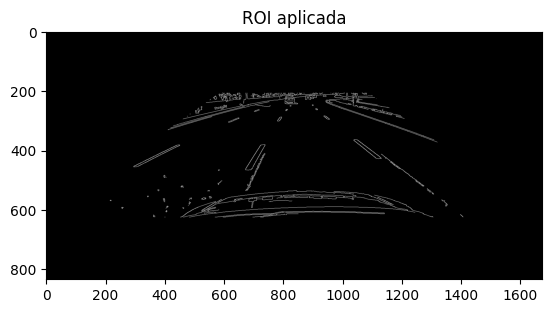

In [13]:
# ==============================
# 3. ROI (REGIÓN DE INTERÉS)
# ==============================
height, width = img_canny.shape

vertices = np.array([[
    (int(width * 0.0), int(height * 0.75)),   # abajo izquierda
    (int(width * 0.35), int(height * 0.25)),  # arriba izquierda
    (int(width * 0.65), int(height * 0.25)),  # arriba derecha
    (int(width * 1.0), int(height * 0.75))    # abajo derecha
]], dtype=np.int32)

# Crear máscara
img_roi = np.zeros_like(img_canny)
cv2.fillPoly(img_roi, vertices, 255)

# Aplicar máscara
img_mask = cv2.bitwise_and(img_canny, img_roi)

plt.imshow(img_mask, cmap='gray')
plt.title("ROI aplicada")
plt.show()

#### 4. TRANSFORMADA DE HOUGH

Líneas detectadas por Hough: 85
Líneas izquierdas filtradas: 6
Líneas derechas filtradas: 5


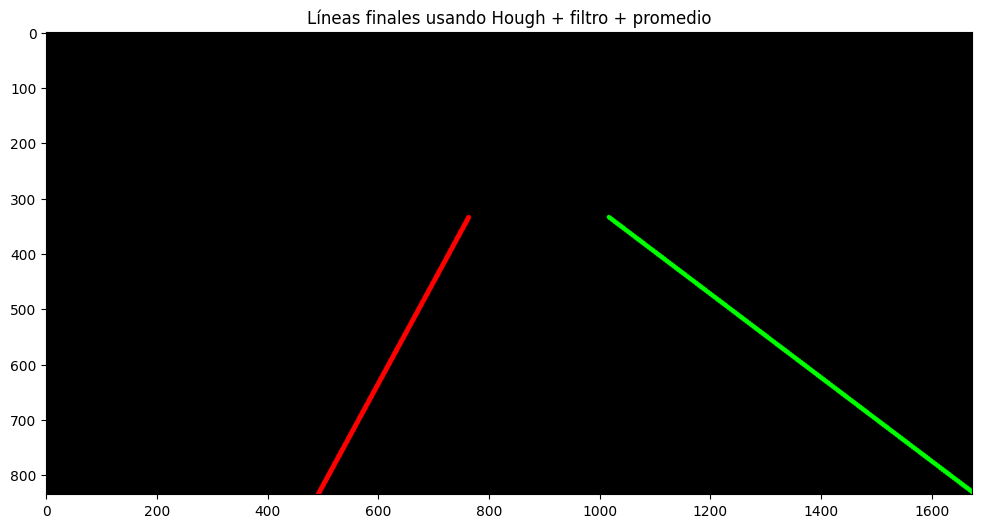

In [19]:
# ============================================
# 4. TRANSFORMADA DE HOUGH MEJORADA
# ============================================

# Parámetros de Hough
rho = 2                         # Resolución en píxeles
theta = np.pi / 180             # Resolución angular en radianes
threshold = 80                  # Número mínimo de votos para aceptar una línea
min_line_len = 100              # Longitud mínima de línea
max_line_gap = 50               # Separación máxima entre segmentos para unirlos

# Detectar segmentos de línea usando HoughLinesP
lines = cv2.HoughLinesP(
    img_mask,                   # Imagen con Canny + ROI aplicada
    rho,
    theta,
    threshold,
    np.array([]),
    minLineLength=min_line_len,
    maxLineGap=max_line_gap
)

# Imagen vacía donde se dibujarán las líneas finales
img_lines = np.zeros((height, width, 3), dtype=np.uint8)

# Listas para guardar líneas izquierda y derecha
left_lines = []
right_lines = []

# Filtros de pendiente
min_slope = 0.5                 # Elimina líneas casi horizontales
max_slope = 2.5                 # Elimina líneas demasiado verticales

# ============================================
# FILTRAR LÍNEAS POR PENDIENTE
# ============================================

if lines is not None:
    for line in lines:
        for x1, y1, x2, y2 in line:

            # Evitar división entre cero
            if x2 - x1 == 0:
                continue

            # Calcular pendiente e intercepto
            slope = (y2 - y1) / (x2 - x1)
            intercept = y1 - slope * x1

            # Eliminar líneas horizontales o demasiado verticales
            if abs(slope) < min_slope:
                continue

            if abs(slope) > max_slope:
                continue

            # Separar líneas por lado
            # En imágenes, y crece hacia abajo
            if slope < 0:
                left_lines.append((slope, intercept))
            else:
                right_lines.append((slope, intercept))

print("Líneas detectadas por Hough:", len(lines) if lines is not None else 0)
print("Líneas izquierdas filtradas:", len(left_lines))
print("Líneas derechas filtradas:", len(right_lines))


# ============================================
# FUNCIÓN PARA CREAR UNA LÍNEA COMPLETA
# ============================================

def make_line(height, slope, intercept):
    """
    Convierte pendiente e intercepto en dos puntos x1,y1,x2,y2.
    Esto permite dibujar una línea larga en lugar de muchos segmentos pequeños.
    """

    y1 = height                  # Parte inferior de la imagen
    y2 = int(height * 0.40)      # Parte superior de la línea dentro del ROI

    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)

    return x1, y1, x2, y2


# ============================================
# PROMEDIAR Y DIBUJAR LÍNEA IZQUIERDA
# ============================================

if len(left_lines) > 0:
    left_avg = np.mean(left_lines, axis=0)
    left_slope = left_avg[0]
    left_intercept = left_avg[1]

    x1, y1, x2, y2 = make_line(height, left_slope, left_intercept)

    # Dibujar línea izquierda en rojo
    cv2.line(img_lines, (x1, y1), (x2, y2), (255, 0, 0), 8)


# ============================================
# PROMEDIAR Y DIBUJAR LÍNEA DERECHA
# ============================================

if len(right_lines) > 0:
    right_avg = np.mean(right_lines, axis=0)
    right_slope = right_avg[0]
    right_intercept = right_avg[1]

    x1, y1, x2, y2 = make_line(height, right_slope, right_intercept)

    # Dibujar línea derecha en verde
    cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 8)


# ============================================
# MOSTRAR LÍNEAS DETECTADAS
# ============================================

plt.figure(figsize=(12, 6))
plt.imshow(img_lines)
plt.title("Líneas finales usando Hough + filtro + promedio")
plt.show()

#### 5. OVERLAY FINAL

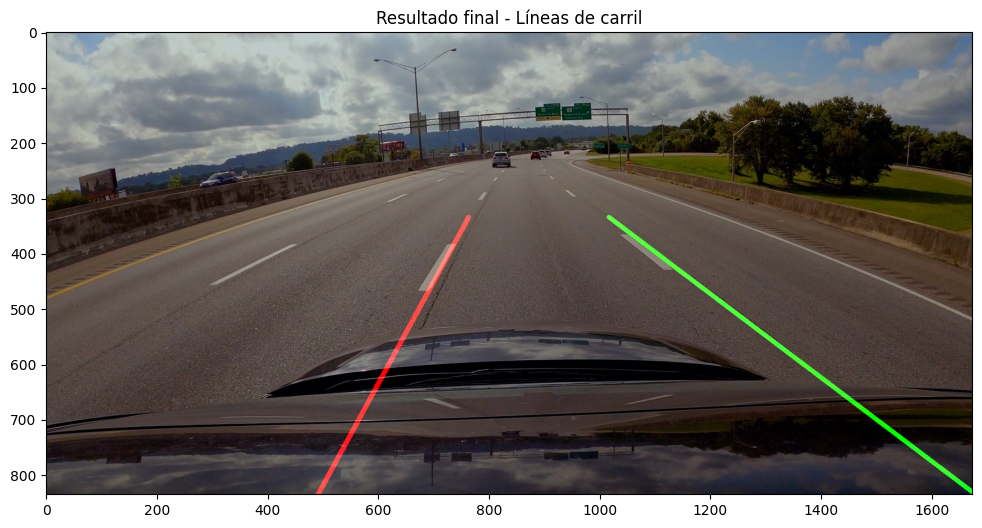

In [20]:
# ============================================
# 5. OVERLAY FINAL
# ============================================

alpha = 0.8
beta = 1.0
gamma = 0.0

# Convertir imagen original BGR a RGB para matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Combinar imagen original con las líneas detectadas
img_lane_lines = cv2.addWeighted(img_rgb, alpha, img_lines, beta, gamma)

plt.figure(figsize=(12, 6))
plt.imshow(img_lane_lines)
plt.title("Resultado final - Líneas de carril")
plt.show()

🔴 ¿Qué es la Transformada de Hough?

Es un método para detectar líneas rectas en una imagen.

👉 No trabaja directamente en la imagen

👉 Trabaja en un espacio matemático (ρ, θ)

#### 🧠 Idea clave (la más importante)

Cada punto blanco (edge) en tu imagen puede pertenecer a MUCHAS líneas posibles.

Entonces Hough hace esto:

Toma un punto (x, y)

Calcula todas las líneas posibles que pasan por ese punto

Vota en un “mapa acumulador”

Donde hay muchas intersecciones → hay una línea real

📐 Ecuación que usa

ρ=xcos(θ)+ysin(θ)

ρ = distancia desde el origen

θ = ángulo de la línea

🔄 ¿Cómo se ve el proceso?

1. Imagen con bordes (tu Canny)

Solo píxeles blancos (edges)

2. Cada punto vota en (ρ, θ)

Se crea un “mapa de votos”

3. Picos en el mapa = líneas detectadas

🚗 Aplicado a tu código

#### Tu pipeline es correcto:

1. Canny

✔ Detecta bordes

✔ Pero detecta MUCHÍSIMO ruido

2. ROI

✔ Bien aplicado

✔ Quitaste cielo → 👍

3. HoughLinesP

Aquí está el problema principal 👇

threshold = 40

min_line_len = 50

max_line_gap = 100

#### 👉 Esto está demasiado permisivo

Resultado:

Detecta TODO

Incluye ruido

Genera ese “spaghetti rojo” que ves

⚠️ ¿Por qué tu resultado está mal?

#### En tu imagen final:

Detecta líneas del cofre 🚗

Detecta ruido del asfalto

Detecta sombras

Detecta bordes pequeños


#### 👉 No está filtrando “líneas de carril”, solo “cualquier línea”

#### IMPLEMENTADO PARA VIDEO MP4

## CHULADA

In [6]:
def smooth_line(current_line, previous_line, alpha=0.2):
    """
    Suaviza la línea actual usando la línea del frame anterior.
    Evita que las líneas parpadeen frame a frame.
    """

    if current_line is None:
        return previous_line

    if previous_line is None:
        return current_line

    return [
        int(alpha * current_line[0] + (1 - alpha) * previous_line[0]),
        int(alpha * current_line[1] + (1 - alpha) * previous_line[1]),
        int(alpha * current_line[2] + (1 - alpha) * previous_line[2]),
        int(alpha * current_line[3] + (1 - alpha) * previous_line[3])
    ]

In [8]:
import cv2
import numpy as np

# ==============================
# VARIABLES PARA SUAVIZADO TEMPORAL
# ==============================

left_line_prev = None
right_line_prev = None

alpha_smooth = 0.2   # 0.1 muy suave, 0.3 más reactivo



# Ruta del video
video_path = "../../data/Video/5382495-uhd_3840_2160_24fps.mp4"
#video_path = "../../data/Video/city_2025a_05062026.mp4"

cap = cv2.VideoCapture(video_path)

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    # ======================================
    # PIPELINE (igual que  imagen)
    # ======================================

    # 1. Convertir a gris
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 2. Blur para reducir ruido
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # 3. Canny
    edges = cv2.Canny(blur, 100, 200)

    # 4. ROI
    height, width = edges.shape

    mask = np.zeros_like(edges)

    vertices = np.array([[
    (0, height * 0.6),             # sube el límite inferior
    (width * 0.45, height * 0.5),
    (width * 0.55, height * 0.5),
    (width, height * 0.6)
]], dtype=np.int32)

    cv2.fillPoly(mask, vertices, 255)
    img_mask = cv2.bitwise_and(edges, mask)

    # ======================================
    # HOUGH + FILTRO + PROMEDIO
    # ======================================

    lines = cv2.HoughLinesP(
        img_mask,
        2,
        np.pi/180,
        80,
        minLineLength=100,
        maxLineGap=50
    )

    img_lines = np.zeros_like(frame)

    left_lines = []
    right_lines = []

    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:

                if x2 - x1 == 0:
                    continue

                slope = (y2 - y1) / (x2 - x1)
                intercept = y1 - slope * x1

                if abs(slope) < 0.5 or abs(slope) > 2.5:
                    continue

                if slope < 0 and x1 < width * 0.5 and x2 < width * 0.5:
                    left_lines.append((slope, intercept))

                elif slope > 0 and x1 > width * 0.5 and x2 > width * 0.5:
                    right_lines.append((slope, intercept))

                if y1 > height * 0.7 or y2 > height * 0.7:
                    continue

    def make_line(height, slope, intercept):
        y1 = int(height * 0.8)
        y2 = int(height * 0.35)
        x1 = int((y1 - intercept) / slope)
        x2 = int((y2 - intercept) / slope)
        return x1, y1, x2, y2

    # Dibujar líneas promedio
    left_current = None
    right_current = None

    if len(left_lines) > 0:
        left_avg = np.mean(left_lines, axis=0)
        left_current = make_line(height, left_avg[0], left_avg[1])

    if len(right_lines) > 0:
        right_avg = np.mean(right_lines, axis=0)
        right_current = make_line(height, right_avg[0], right_avg[1])   

    #Suavisar
    left_line_prev = smooth_line(left_current, left_line_prev, alpha_smooth)
    right_line_prev = smooth_line(right_current, right_line_prev, alpha_smooth)

    #Dibujar lineas suavisadas
    if left_line_prev is not None:
        x1, y1, x2, y2 = left_line_prev
        cv2.line(img_lines, (x1, y1), (x2, y2), (255, 0, 0), 40)

    if right_line_prev is not None:
        x1, y1, x2, y2 = right_line_prev
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 40)



    # Overlay
    result = cv2.addWeighted(frame, 0.8, img_lines, 1, 0)


    # Mostrar video
    cv2.imshow("Lane Detection", cv2.resize(result, (800, 450)))

    # Presiona 'q' para salir
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

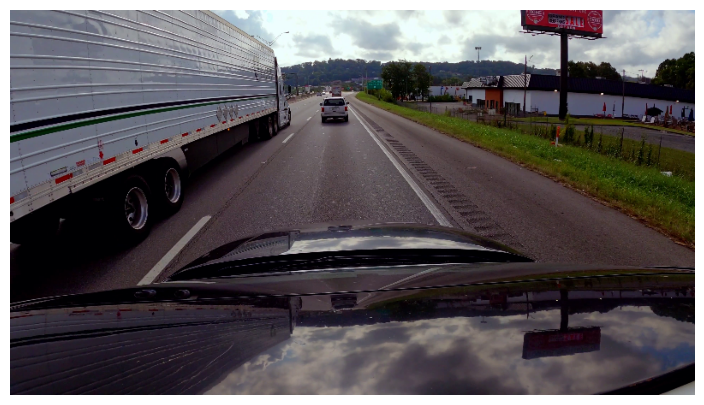

In [52]:
import cv2
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

video_path = "../../data/Video/5382495-uhd_3840_2160_24fps.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: no se pudo abrir el video. Revisa la ruta.")
else:
    while True:
        ret, frame = cap.read()

        if not ret:
            break

        # Reducir tamaño para que no sea tan pesado
        frame = cv2.resize(frame, (800, 450))

        # OpenCV usa BGR, matplotlib usa RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 5))
        plt.imshow(frame_rgb)
        plt.axis("off")
        display(plt.gcf())
        clear_output(wait=True)
        plt.close()

cap.release()